## Supervised learning approach to estimate probability of default (PD)

Here we implement a simple 2-layered neural network (NN) to estimate the probability of default given a data set

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## The data

In order to provide reproducible, I will rely on the data from Kaggle competition Give Me Some Credit (https://www.kaggle.com/c/GiveMeSomeCredit).

In [2]:
# We load & prepare data (Give Me Some Credit) =====
# Put the CSV at: data/cs-training.csv
df = pd.read_csv("data/GiveMeSomeCredit/cs-training.csv", index_col = 0)

# Target and features
y_all = df["SeriousDlqin2yrs"].values.reshape(-1, 1)  # (N,1)
X_all = df.drop(columns=["SeriousDlqin2yrs"])
X_all = X_all.select_dtypes(include=[np.number]).values  # we keep numeric only

rng = np.random.default_rng(0)

In [3]:
n_default = (y_all == 1).sum()
n_total = len(y_all)
print(n_default, "defaulters")
print(f"{n_default / n_total:.2%} of rows")


10026 defaulters
6.68% of rows


We check how 'incomplete' the data is

In [4]:
X_df = df.drop(columns=["SeriousDlqin2yrs"], errors="ignore")

# number of rows with ≥1 NaN
n_rows_with_nan = X_df.isna().any(axis=1).sum() # Here we count the number of rows with at least one NaN
n_rows_total = len(X_df)

print(n_rows_with_nan, "rows with at least one NaN")
print(f"{n_rows_with_nan/n_rows_total:.2%} of rows")

29731 rows with at least one NaN
19.82% of rows


## Input
We clean the data first. There are some data points that contain NaN. We use imputer and scaler functions of sci-kit learn to set those NaN to the median value of a given array.

In [5]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_val   = scaler.transform(imputer.transform(X_val_raw))


In [6]:
n_default = (y_val == 1).sum()
n_total = len(y_val)
print(n_default, "defaulters")
print(f"{n_default / n_total:.2%} of rows")


2005 defaulters
6.68% of rows


In [7]:
n_default = (y_train == 1).sum()
n_total = len(y_train)
print(n_default, "defaulters")
print(f"{n_default / n_total:.2%} of rows")


8021 defaulters
6.68% of rows


# TensorFlow implementation
Let's do the same exercise using established libraries

In [8]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# ---------- Custom winsorizer (clips extremes by quantiles) ----------
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, low=0.01, high=0.99):
        self.low = low
        self.high = high

    def fit(self, X, y=None):
        X = np.asarray(X)
        self.lo_ = np.nanquantile(X, self.low, axis=0)
        self.hi_ = np.nanquantile(X, self.high, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.clip(X, self.lo_, self.hi_)

# ---------- Example: split columns ----------
# If you have a DataFrame:
# numeric_cols = X_df.columns.tolist()
# log_cols = [...]  # choose subset of numeric_cols
# other_cols = [c for c in numeric_cols if c not in log_cols]

# If you only have numpy arrays and no names, choose by indices:
d = X_all.shape[1]
log_idx = []          # put indices of heavy-tailed columns here
other_idx = [i for i in range(d) if i not in log_idx]

# log1p transformer (works for non-negative data)
log1p = FunctionTransformer(lambda x: np.log1p(np.maximum(x, 0.0)), feature_names_out="one-to-one")

log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),  # adds missingness flags
    ("clip", QuantileClipper(0.01, 0.99)),
    ("log1p", log1p),
    ("scaler", StandardScaler()),
])

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("clip", QuantileClipper(0.01, 0.99)),
    ("scaler", StandardScaler()),
])

preprocess_nn = ColumnTransformer(
    transformers=[
        ("log", log_pipe, log_idx),
        ("num", num_pipe, other_idx),
    ],
    remainder="drop"
)

# ---------- Split first ----------
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# ---------- Fit on train, transform both ----------
X_train_tf = preprocess_nn.fit_transform(X_train_raw).astype(np.float32)
X_val_tf   = preprocess_nn.transform(X_val_raw).astype(np.float32)



In [9]:
# ===================== FIXED: PIPELINE PREPROCESSING + TF TRAINING (CONSISTENT VARIABLES) =====================

import numpy as np
import tensorflow as tf

# You already created:
# X_train_raw, X_val_raw, y_train, y_val
# X_train_tf, X_val_tf  (from preprocess_nn)

# -----------------------------
# Data preparation (DO NOT redefine X_train_tf/X_val_tf from X_train/X_val)
# -----------------------------
# Just ensure correct dtype for TF (ColumnTransformer may return float64)
X_train_tf = X_train_tf.astype(np.float32)
X_val_tf   = X_val_tf.astype(np.float32)

y_train_tf = y_train.astype(np.float32).reshape(-1, 1)
y_val_tf   = y_val.astype(np.float32).reshape(-1, 1)

d = X_train_tf.shape[1]

H1 = 128
H2 = 64

# -----------------------------
# Model: 2 hidden layers
# -----------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(d,)),
    tf.keras.layers.Dense(H1, activation="relu", kernel_initializer=tf.keras.initializers.HeNormal()),
    tf.keras.layers.Dense(H2, activation="relu", kernel_initializer=tf.keras.initializers.HeNormal()),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# -----------------------------
# Compile
# -----------------------------
lr = 1e-3
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc", curve="ROC"),
        tf.keras.metrics.AUC(name="auc_pr", curve="PR"),
    ]
)

# -----------------------------
# Early stopping
# (recommend: smaller min_delta; 1e-3 can be too aggressive for BCE)
# -----------------------------
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=30,
    min_delta=1e-4,
    restore_best_weights=True
)

# -----------------------------
# Class weights (imbalance)
# -----------------------------
pos = float((y_train_tf == 1).sum())
neg = float((y_train_tf == 0).sum())
class_weight = {0: 1.0, 1: (neg / pos) if pos > 0 else 1.0}

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=1000,
    batch_size=256,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1
)

# -----------------------------
# Predict PD
# -----------------------------
probs_val_tf = model.predict(X_val_tf, batch_size=4096).ravel()


2026-02-07 07:16:30.114213: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/1000
469/469 [==============================] - 2s 2ms/step - loss: 0.9004 - auc_roc: 0.8511 - auc_pr: 0.3598 - val_loss: 0.4449 - val_auc_roc: 0.8618 - val_auc_pr: 0.3853
Epoch 2/1000
469/469 [==============================] - 1s 2ms/step - loss: 0.8726 - auc_roc: 0.8602 - auc_pr: 0.3797 - val_loss: 0.4521 - val_auc_roc: 0.8659 - val_auc_pr: 0.3915
Epoch 3/1000
469/469 [==============================] - 1s 2ms/step - loss: 0.8663 - auc_roc: 0.8623 - auc_pr: 0.3859 - val_loss: 0.3997 - val_auc_roc: 0.8632 - val_auc_pr: 0.3857
Epoch 4/1000
469/469 [==============================] - 1s 1ms/step - loss: 0.8622 - auc_roc: 0.8638 - auc_pr: 0.3876 - val_loss: 0.4463 - val_auc_roc: 0.8618 - val_auc_pr: 0.3946
Epoch 5/1000
469/469 [==============================] - 1s 1ms/step - loss: 0.8593 - auc_roc: 0.8646 - auc_pr: 0.3913 - val_loss: 0.4780 - val_auc_roc: 0.8652 - val_auc_pr: 0.3954
Epoch 6/1000
469/469 [==============================] - 1s 1ms/step - loss: 0.8559 - auc_roc: 0.8658

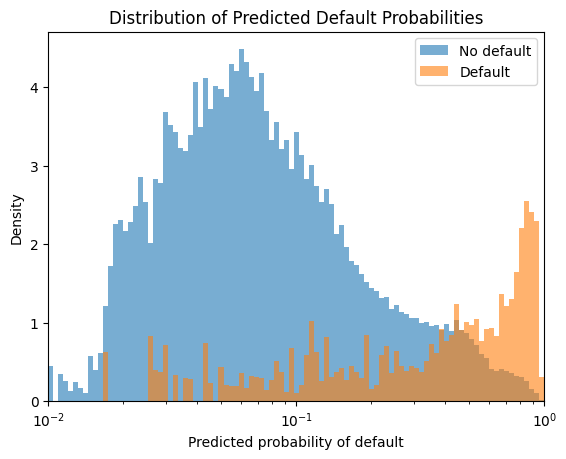

In [19]:
probs_default_tf    = probs_val_tf[y_val.ravel() == 1]
probs_nondefault_tf = probs_val_tf[y_val.ravel() == 0]

#probs_default_tf    = probs_tr_tf[y_train.ravel() == 1]
#probs_nondefault_tf = probs_tr_tf[y_train.ravel() == 0]

probs_tf = probs_val_tf.ravel()

#probs_tf = probs_tr_tf.ravel()


plt.figure()

#plt.hist(probs_tf, bins=np.logspace(-3, 0, 100), density=True, label="total")

plt.hist(probs_nondefault_tf, bins=np.logspace(-2, 0, 100), density=True,
         alpha=0.6, label="No default")

plt.hist(probs_default_tf, bins=np.logspace(-2, 0, 100), density=True,
         alpha=0.6, label="Default")

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")

plt.xscale("log")   
plt.xlim(10**(-2) , 1 )  
plt.title("Distribution of Predicted Default Probabilities")
plt.legend()

plt.show()

8/8 [==============================] - 0s 3ms/step


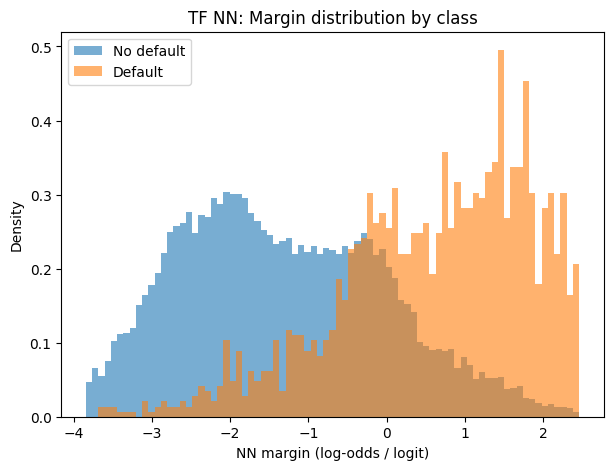

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Predict probabilities on validation
probs_val_tf = model.predict(X_val_tf, batch_size=4096).ravel()

# 2) Convert probs -> margin (logit)
p = np.clip(probs_val_tf, 1e-12, 1 - 1e-12)
margin_tf = np.log(p / (1 - p))

# 3) Split by class
y = y_val_tf.ravel()  # ensure shape (N,)
margin_def = margin_tf[y == 1]
margin_non = margin_tf[y == 0]

# 4) Robust binning (avoid extreme tails)
lo, hi = np.percentile(margin_tf, [1, 99])
bins = np.linspace(lo, hi, 80)

plt.figure(figsize=(7,5))
plt.hist(margin_non, bins=bins, density=True, alpha=0.6, label="No default")
plt.hist(margin_def, bins=bins, density=True, alpha=0.6, label="Default")
plt.xlabel("NN margin (log-odds / logit)")
plt.ylabel("Density")
plt.title("TF NN: Margin distribution by class")
plt.legend()
plt.show()


In [12]:
bins = np.logspace(-3, 0, 35)
bin_ids = np.digitize(probs_tf, bins)

bin_centers_tf = []
obs_rates_tf = []
counts_tf = []
deviation_tf = []
uncertainty_tf = []
standarized_discr_tf = []

for i in range(1, len(bins)):
    mask = bin_ids == i
    if mask.sum() > 50:   # avoid tiny bins
        pi = np.sqrt(bins[i-1]*bins[i])
        ri = y_val_tf[mask].mean()
        ni = mask.sum()
        deltai = ri - pi
        sigmai = np.sqrt(pi*(1-pi)/ni  )
        
        bin_centers_tf.append( pi )
        obs_rates_tf.append( ri )

        deviation_tf.append( deltai )
        uncertainty_tf.append( sigmai )
        standarized_discr_tf.append( deltai/sigmai )
        counts_tf.append( ni )
        
        #print(y_val[mask].mean())
        #print("center is", np.sqrt(bins[i-1]*bins[i]))
        #print("bin(i-1) is ", bins[i-1])
        #print("bin(i) is ", bins[i])
        #print("average is ", (bins[i]+bins[i-1])/2)

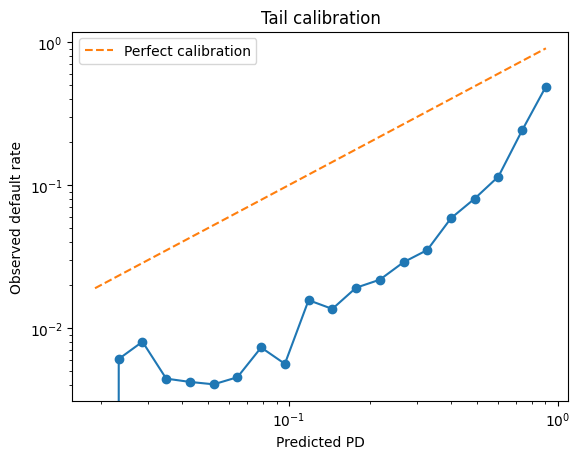

In [13]:
plt.figure()
plt.plot(bin_centers_tf, obs_rates_tf, "o-")
plt.plot(bin_centers_tf, bin_centers_tf, "--", label="Perfect calibration")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.legend()
plt.title("Tail calibration")
plt.show()

In [14]:
# ===================== XGBOOST PD BASELINE (EARLY STOPPING + IMBALANCE, NO SCALING) =====================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
import xgboost as xgb

# -------------------------------------------------------------------
# 0) Split FIRST (prevents leakage)
# -------------------------------------------------------------------
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# -------------------------------------------------------------------
# 1) Preprocess: impute only (NO StandardScaler for trees)
# -------------------------------------------------------------------
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

X_train = preprocess.fit_transform(X_train_raw)
X_val   = preprocess.transform(X_val_raw)

# Ensure labels are 0/1 int
y_train = y_train.astype(int)
y_val   = y_val.astype(int)

In [15]:

# -------------------------------------------------------------------
# 2) Handle imbalance via scale_pos_weight ≈ (#neg / #pos)
# -------------------------------------------------------------------
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = (n_neg / n_pos) if n_pos > 0 else 1.0

# -------------------------------------------------------------------
# 3) Train XGBoost with early stopping on validation
# -------------------------------------------------------------------
params = dict(
    objective="binary:logistic",
    eval_metric=["logloss", "auc", "aucpr"],
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)

bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=5000,          # upper bound (early stopping decides actual)
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=50
)

# -------------------------------------------------------------------
# 4) Predict PD and evaluate
# -------------------------------------------------------------------
best_iter = bst.best_iteration
pd_val = bst.predict(dval, iteration_range=(0, best_iter + 1))

print("Best iteration:", best_iter)
print("VAL ROC-AUC :", roc_auc_score(y_val, pd_val))
print("VAL PR-AUC  :", average_precision_score(y_val, pd_val))
print("VAL LogLoss :", log_loss(y_val, np.clip(pd_val, 1e-12, 1 - 1e-12)))

# -------------------------------------------------------------------
# 5) Optional: Calibrate probabilities (Platt scaling via cv)
# -------------------------------------------------------------------
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV

xgb_sklearn = XGBClassifier(
    n_estimators=best_iter + 1,         # match best boosting round
    learning_rate=params["learning_rate"],
    max_depth=params["max_depth"],
    min_child_weight=params["min_child_weight"],
    subsample=params["subsample"],
    colsample_bytree=params["colsample_bytree"],
    reg_lambda=params["reg_lambda"],
    reg_alpha=params["reg_alpha"],
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
)

xgb_sklearn.fit(X_train, y_train)

cal = CalibratedClassifierCV(xgb_sklearn, method="sigmoid", cv=5)
cal.fit(X_train, y_train)

pd_val_cal = cal.predict_proba(X_val)[:, 1]

print("CAL VAL ROC-AUC :", roc_auc_score(y_val, pd_val_cal))
print("CAL VAL PR-AUC  :", average_precision_score(y_val, pd_val_cal))
print("CAL VAL LogLoss :", log_loss(y_val, np.clip(pd_val_cal, 1e-12, 1 - 1e-12)))


[0]	train-logloss:0.67744	train-auc:0.81558	train-aucpr:0.35667	val-logloss:0.67739	val-auc:0.81890	val-aucpr:0.34851
[50]	train-logloss:0.45961	train-auc:0.86765	train-aucpr:0.41614	val-logloss:0.46137	val-auc:0.86620	val-aucpr:0.39922
[100]	train-logloss:0.44227	train-auc:0.87466	train-aucpr:0.43139	val-logloss:0.44594	val-auc:0.86869	val-aucpr:0.40520
[150]	train-logloss:0.43519	train-auc:0.88038	train-aucpr:0.43990	val-logloss:0.44104	val-auc:0.86906	val-aucpr:0.40621
[200]	train-logloss:0.42949	train-auc:0.88504	train-aucpr:0.44727	val-logloss:0.43730	val-auc:0.86881	val-aucpr:0.40710
[247]	train-logloss:0.42451	train-auc:0.88885	train-aucpr:0.45388	val-logloss:0.43415	val-auc:0.86828	val-aucpr:0.40649
Best iteration: 197
VAL ROC-AUC : 0.8687895549570439
VAL PR-AUC  : 0.40759011164496817
VAL LogLoss : 0.43755165225412335


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


CAL VAL ROC-AUC : 0.869013739984741
CAL VAL PR-AUC  : 0.4061514581775704
CAL VAL LogLoss : 0.17744007015761556


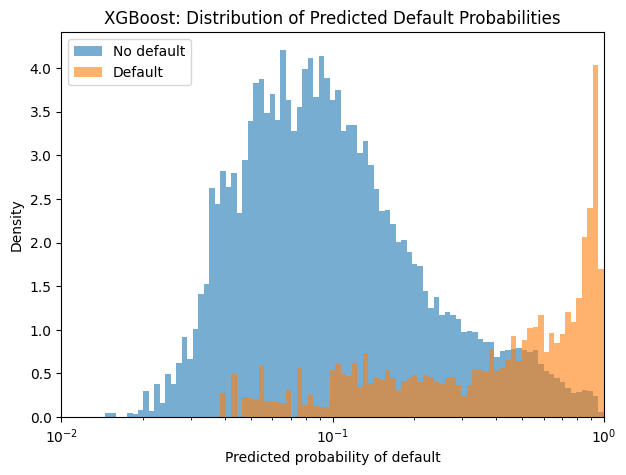

In [18]:
import numpy as np
import matplotlib.pyplot as plt

y_val_flat = y_val.ravel()   # or y_val.squeeze()

# Split by class
probs_default_xgb    = pd_val[y_val_flat == 1]
probs_nondefault_xgb = pd_val[y_val_flat == 0]
probs_xgb            = pd_val


plt.figure(figsize=(7,5))

#plt.hist(
#    probs_xgb,
#    bins=np.logspace(-2, 0, 100),
#    density=True,
#    label="total"
#)

plt.hist(
    probs_nondefault_xgb,
    bins=np.logspace(-2, 0, 100),
    density=True,
    alpha=0.6,
    label="No default"
)

plt.hist(
    probs_default_xgb,
    bins=np.logspace(-2, 0, 100),
    density=True,
    alpha=0.6,
    label="Default"
)

plt.xlabel("Predicted probability of default")
plt.ylabel("Density")
plt.xscale("log")
plt.xlim(1e-2, 1.0)
plt.title("XGBoost: Distribution of Predicted Default Probabilities")
plt.legend()
plt.show()


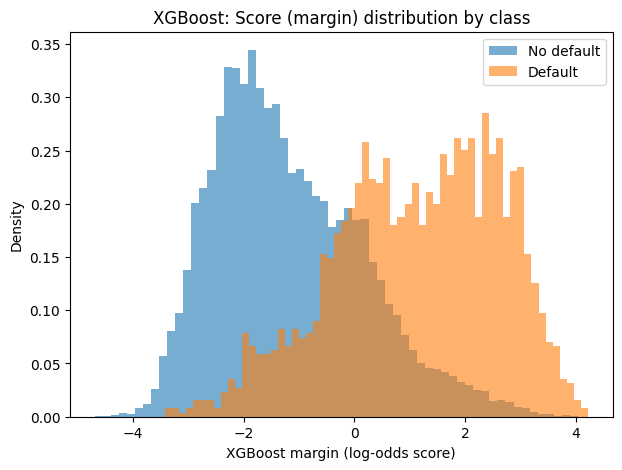

In [17]:
import matplotlib.pyplot as plt

y_val_flat = y_val.ravel()

margin_val = bst.predict(dval, output_margin=True)

margin_default_xgb    = margin_val[y_val_flat == 1]
margin_nondefault_xgb = margin_val[y_val_flat == 0]

plt.figure(figsize=(7,5))

plt.hist(
    margin_nondefault_xgb,
    bins=60,
    density=True,
    alpha=0.6,
    label="No default"
)

plt.hist(
    margin_default_xgb,
    bins=60,
    density=True,
    alpha=0.6,
    label="Default"
)

plt.xlabel("XGBoost margin (log-odds score)")
plt.ylabel("Density")
plt.title("XGBoost: Score (margin) distribution by class")
plt.legend()
plt.show()
